In [15]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import os

In [16]:
# ==========================================
# 1. CONFIGURATION & PATHS
# ==========================================
# Assuming this script is running inside the 'scripts/' folder
BASE_DIR = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else os.path.abspath('../..')
TRAIN_DIR = os.path.join(BASE_DIR, 'dataset', 'train')
VAL_DIR = os.path.join(BASE_DIR, 'dataset', 'value')
MODEL_SAVE_PATH = os.path.join(BASE_DIR, 'models', 'kiosk_face_model_eff.keras')

BATCH_SIZE = 32
IMAGE_SIZE = (224, 224)
EPOCHS = 10

In [17]:
# Ensure the models directory exists
os.makedirs(os.path.dirname(MODEL_SAVE_PATH), exist_ok=True)

In [18]:
# ==========================================
# 2. DATA LOADING
# ==========================================
print("Loading training dataset...")
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE
)

print("Loading validation dataset...")
val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    VAL_DIR,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE
)

# Extract class names dynamically from folder names
class_names = train_dataset.class_names
NUM_CLASSES = len(class_names)
print(f"Detected {NUM_CLASSES} classes: {class_names}")

# Optimize dataset loading for performance
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)

Loading training dataset...
Found 960 files belonging to 4 classes.
Loading validation dataset...
Found 240 files belonging to 4 classes.
Detected 4 classes: ['kailousssssss', 'regine', 'rops', 'wends']


In [19]:
# ==========================================
# 3. ARCHITECTURE DESIGN (Transfer Learning)
# ==========================================
# Data Augmentation Layer to prevent overfitting
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="data_augmentation")

# Load MobileNetV2 without the final classification layers
print("Loading EfficientNetV2B0 backbone...")
base_model = tf.keras.applications.EfficientNetV2B0(
    input_shape=IMAGE_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)

# Freeze the base model so its pre-trained weights aren't destroyed
base_model.trainable = False

# Construct the custom model
inputs = tf.keras.Input(shape=IMAGE_SIZE + (3,))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x) # 30% Dropout to further prevent overfitting
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

# Compile the model (Manual definition required by rubric)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Loading EfficientNetV2B0 backbone...


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,924,436 (22.60 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

In [20]:
# ==========================================
# 4. TRAINING THE MODEL
# ==========================================
print("\nStarting Training...")
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS
)


Starting Training...
Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 232ms/step - accuracy: 0.7063 - loss: 0.9214 - val_accuracy: 0.9833 - val_loss: 0.4680
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 209ms/step - accuracy: 0.9781 - loss: 0.3416 - val_accuracy: 0.9958 - val_loss: 0.2126
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 223ms/step - accuracy: 0.9875 - loss: 0.1903 - val_accuracy: 0.9958 - val_loss: 0.1321
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 218ms/step - accuracy: 0.9906 - loss: 0.1328 - val_accuracy: 0.9958 - val_loss: 0.0979
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 220ms/step - accuracy: 0.9906 - loss: 0.1081 - val_accuracy: 1.0000 - val_loss: 0.0765
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 216ms/step - accuracy: 0.9948 - loss: 0.0804 - val_accuracy: 1.0000 - val_loss: 0.0585
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 224ms/step - accuracy: 0.9958 - loss: 0.0689 - val_accuracy: 1.0000 - val_loss: 0.0511
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 225ms/step - accuracy: 0.9969 - loss: 0.

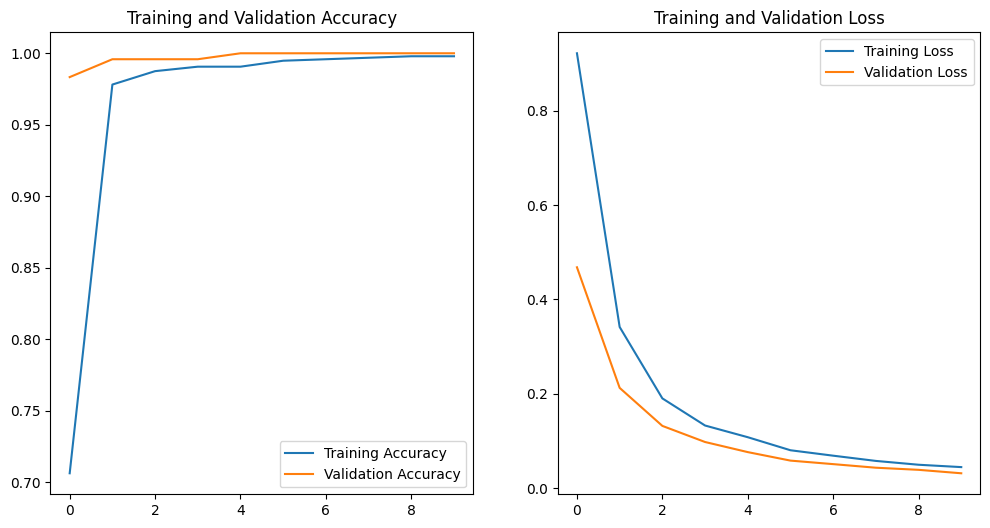

In [21]:
# ==========================================
# 5. MODEL PERFORMANCE EVALUATION (Plotting)
# ==========================================
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 6))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show() # Display the graphs to prove avoidance of overfitting

In [22]:
# ==========================================
# 6. SAVING THE FINAL DELIVERABLE
# ==========================================
model.save(MODEL_SAVE_PATH)
print(f"\n✅ Training complete! Model successfully saved to: {MODEL_SAVE_PATH}")
print(f"Class mapping: {dict(enumerate(class_names))}")


✅ Training complete! Model successfully saved to: /Users/cxnner05/Documents/projects/ml-finals/backend/models/kiosk_face_model_eff.keras
Class mapping: {0: 'kailousssssss', 1: 'regine', 2: 'rops', 3: 'wends'}
